### Respuesta a la Pregunta (a): Dimensión del Espacio de Hilbert

Para determinar la dimensión del espacio de Hilbert total del sistema, debemos analizar los grados de libertad individuales de cada partícula. 

Para un único espín $1/2$, el espacio de Hilbert $\mathcal{H}_i$ está definido por una base de dos estados posibles (espín arriba y espín abajo):
$$\text{Base individual} = \{|\uparrow\rangle, |\downarrow\rangle\}$$
Por lo tanto, la dimensión para un solo espín es $d_i = 2$.

Cuando acoplamos $N$ espines en una cadena, el espacio de Hilbert total del sistema $\mathcal{H}$ se construye matemáticamente mediante el producto tensorial de los espacios individuales de cada espín:
$$\mathcal{H} = \mathcal{H}_1 \otimes \mathcal{H}_2 \otimes \dots \otimes \mathcal{H}_N$$

Una propiedad fundamental del producto tensorial es que la dimensión del espacio resultante es igual al producto de las dimensiones de los espacios originales. Como cada espín aporta un factor de $2$, la dimensión total $d$ en función del número de espines $N$ crece de forma exponencial:
$$d = 2 \times 2 \times \dots \times 2 = 2^N$$

**Conclusión:** La dimensión del espacio de Hilbert para una cadena de $N$ espines $1/2$ es **$2^N$**.

In [2]:
import numpy as np

def hamiltoniano_ising(N, J, B):
    """
    Arma el Hamiltoniano del modelo de Ising transversal.
    N: espines, J: interacción, B: campo magnético.
    """
    # 1. Pauli básicas (en complejo, porque la física cuántica lo exige)
    I = np.array([[1, 0], [0, 1]], dtype=complex)
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    
    # El famoso 2^N. Ojo con poner N > 12 o la RAM va a pedir auxilio.
    dim = 2**N 
    
    # Lienzo en blanco
    H = np.zeros((dim, dim), dtype=complex)
    
    # 2. Término del Campo Transversal (B * sz)
    for i in range(N):
        ops = [I] * N
        ops[i] = sz  # Clavamos sigma_z en la posición i
        
        # Tensor product en cadena para inflar esto al espacio de Hilbert
        bloque_b = ops[0]
        for j in range(1, N):
            bloque_b = np.kron(bloque_b, ops[j]) # np.kron hace el trabajo sucio
            
        H += B * bloque_b

    # 3. Interacción vecinos más cercanos (J * sx_i * sx_{i+1})
    for i in range(N - 1): # Hasta N-1 porque el último no tiene a quién molestar a su derecha
        ops = [I] * N
        ops[i] = sx
        ops[i+1] = sx # El vecino
        
        # Misma historia, multiplicamos todo en cadena
        bloque_j = ops[0]
        for j in range(1, N):
            bloque_j = np.kron(bloque_j, ops[j])
            
        H += J * bloque_j
        
    return H

# Pruebita de sanidad mental
H_test = hamiltoniano_ising(N=2, J=1.0, B=0.5)

# Si esto no da (4, 4) me pongo triste
print(f"Dimensiones de H (N=2): {H_test.shape}")

Dimensiones de H (N=2): (4, 4)


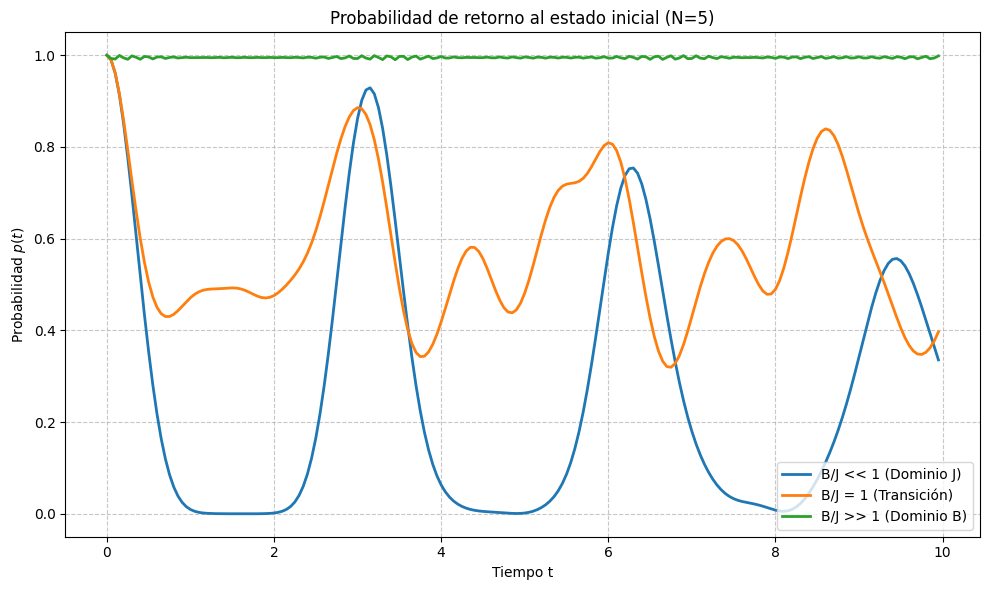

In [3]:
import matplotlib.pyplot as plt
from scipy.linalg import expm # El martillo pesado para exponenciales de matrices

# Parámetros (N=5 porque queremos resultados hoy porfis)
n_spins = 5 
J = 1.0
dt = 0.05
# Rango de tiempo, de 0 a 10 dando pasitos de dt
t_steps = np.arange(0.0, 10.0, dt)

# Estado inicial: todos los espines hacia abajo (el fondo del pozo)
# Es un vector de ceros salvo por un humilde 1 al final
dim = 2**n_spins
psi_0 = np.zeros(dim, dtype=complex)
psi_0[-1] = 1.0 

# Casos de prueba (campo B vs interacción J)
b_vals = [0.1, 1.0, 10.0]
labels = ['B/J << 1 (Dominio J)', 'B/J = 1 (Transición)', 'B/J >> 1 (Dominio B)']

plt.figure(figsize=(10, 6))

for B, label in zip(b_vals, labels):
    
    # Reciclamos tu función anterior
    H = hamiltoniano_ising(n_spins, J, B)
    
    # EL TRUCO DE SUPERVIVENCIA COMPUTACIONAL
    # Calcular expm() de una matriz enorme en cada paso del ciclo es un suicidio para la CPU.
    # Como H es constante, calculamos la evolución de un pasito (dt) una sola vez acá afuera.
    # Si lo metíamos al for...
    U_dt = expm(-1j * H * dt)
    
    probs = []
    psi_t = psi_0.copy() # Copia profunda para no arruinar el estado original por accidente
    
    for t in t_steps:
        # Overlap: qué tanto se parece el estado actual al inicial
        # Usamos vdot porque conjuga el primer vector (clave para que la cuántica no explote)
        overlap = np.vdot(psi_0, psi_t)
        probs.append(np.abs(overlap)**2)
        
        # Avanzamos al futuro multiplicando matriz por vector. 
        # Esto es infinitamente más amable con la RAM y la paciencia.
        psi_t = np.dot(U_dt, psi_t)
        
    # Dibujamos la curva para este valor de B específico
    plt.plot(t_steps, probs, label=label, linewidth=2)

# Maquillaje final para que el gráfico sea presentable
plt.title(f'Probabilidad de retorno al estado inicial (N={n_spins})')
plt.xlabel('Tiempo t')
plt.ylabel('Probabilidad $p(t)$') 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Para que nada quede recortado
plt.show() # A ver qué salió

In [7]:
import time
import numpy as np

# Tamaños del sistema exigidos por el enunciado
N_valores = [4, 5, 6, 7, 8]

# Fijamos J y B a valores estándar para la prueba
J_test = 1.0
B_test = 1.0

# Listas vacías para ir guardando nuestros resultados (las usaremos en la parte e)
tiempos_ejecucion = []

print("Iniciando benchmark cuántico... (Paciencia para N=8)\n")
print("-" * 50)
print(f"{'N espines':<15} | {'Dimensión (2^N)':<15} | {'Tiempo (segundos)':<15}")
print("-" * 50)

for N in N_valores:
    # 1. Encendemos el cronómetro de alta precisión
    inicio = time.perf_counter()
    
    # 2. Construimos el Hamiltoniano (usando tu función pitónica)
    H = hamiltoniano_ising(N, J_test, B_test)
    
    # 3. Diagonalizamos la matriz densa
    # Usamos eigh porque sabemos que H es Hermítica (autovalores reales)
    # Esto es el cuello de botella O(d^3) absoluto
    evals, evecs = np.linalg.eigh(H)
    
    # 4. Detenemos el cronómetro
    fin = time.perf_counter()
    
    # Calculamos el tiempo transcurrido
    tiempo_total = fin - inicio
    tiempos_ejecucion.append(tiempo_total)
    
    # Imprimimos los resultados en formato de tabla para que se vea elegante
    dim_H = 2**N
    print(f"{N:<15} | {dim_H:<15} | {tiempo_total:.6f} s")

print("-" * 50)
print("\n¡Sobrevivimos! Datos recolectados con éxito para la gráfica.")

Iniciando benchmark cuántico... (Paciencia para N=8)

--------------------------------------------------
N espines       | Dimensión (2^N) | Tiempo (segundos)
--------------------------------------------------
4               | 16              | 0.001292 s
5               | 32              | 0.001609 s
6               | 64              | 0.003140 s
7               | 128             | 0.015004 s
8               | 256             | 0.051384 s
--------------------------------------------------

¡Sobrevivimos! Datos recolectados con éxito para la gráfica.


Despertando a la CPU...

Iniciando masacre computacional promediada...
N = 4  | Tiempo medio: 0.000126 s
N = 5  | Tiempo medio: 0.000493 s
N = 6  | Tiempo medio: 0.000702 s
N = 7  | Tiempo medio: 0.007947 s
N = 8  | Tiempo medio: 0.034541 s


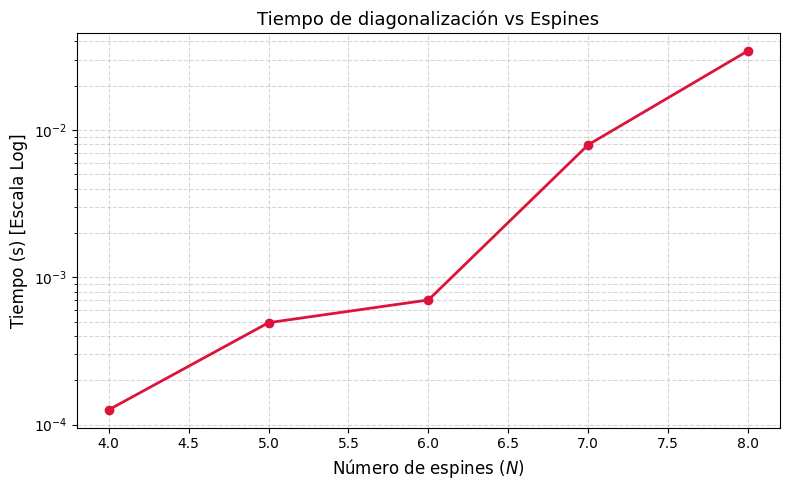

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Parámetros 
spins = [4, 5, 6, 7, 8] 
J = 1.0
B = 1.0
corridas = 10 # 10 repeticiones por cada N para el ruido de fondo del SO

# Evitamos el cold start el primer llamado a las rutinas de numpy siempre es lentou
print("Despertando a la CPU...")
_ = np.linalg.eigh(np.random.rand(16, 16)) # jijaja

t_promedios = []

print("\nIniciando masacre computacional promediada...")
for n in spins:
    t_parciales = []
    
    for _ in range(corridas):
        # Asumimos que hamiltoniano_ising está definida por ahí arriba
        H = hamiltoniano_ising(n, J, B)
        
        # Cronómetro fino. Solo medimos el eigh para no ensuciar el dato con la creación de la matriz
        inicio = time.perf_counter()
        np.linalg.eigh(H)
        fin = time.perf_counter()
        
        t_parciales.append(fin - inicio)
        
    # Promediamos las 10 vueltas y guardamos
    t_medio = np.mean(t_parciales)
    t_promedios.append(t_medio)
    
    print(f"N = {n:<2} | Tiempo medio: {t_medio:.6f} s")

# Gráfico para justificar el uso del servidor
plt.figure(figsize=(8, 5))

# Ploteo estándar
plt.plot(spins, t_promedios, marker='o', linestyle='-', color='crimson', linewidth=2)

# LA CLAVE DEL ÉXITO: Eje Y logarítmico. 
# El espacio de Hilbert crece a 2^N y eigh pide O(d^3).
# Si la matemática y NumPy no mienten, esto tiene que verse como una línea recta perfecta.
plt.yscale('log') 

plt.title('Tiempo de diagonalización vs Espines', fontsize=13)
plt.xlabel('Número de espines ($N$)', fontsize=12)
plt.ylabel('Tiempo (s) [Escala Log]', fontsize=12)

# Grilla secundaria para que se note bien que la escala es logarítmica
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show() # A rezar para que dé una recta

In [20]:
import numpy as np

# 1. Los datos de la realidad
n_vals = np.array([4, 5, 6, 7, 8])







# 2. Ajuste exponencial (magia oscura con logaritmos)
m, c = np.polyfit(n_vals, np.log(t_promedios), 1)

# 3. La bola de cristal
def cuanto_falta(n_target):
    # Deshacemos el logaritmo: T = e^(m*N + c)
    return np.exp(m * n_target + c)

# 4. Cuando la ambición supera a la RAM
n_extremos = [20, 50, 100]

print("Predicción de tiempos para el desastre computacional:")
print(f"Modelo ajustado: T(N) = exp({m:.4f} * N + {c:.4f}) segundos\n")

for n in n_extremos:
    t_est = cuanto_falta(n)
    
    # 2^N es la dimensión, pero el espacio de Hilbert es implacable
    print(f"N = {n:<3} | Matriz: 2^{n} x 2^{n}")
    
    # Formateo condicional para no tener que leer 1e50 segundos en la terminal
    if t_est < 60:
        print(f" -> {t_est:.2f} seg (Respira tranquilo)")
    elif t_est < 3600:
        print(f" -> {t_est/60:.2f} min (Ve por un café)")
    elif t_est < 86400:
        print(f" -> {t_est/3600:.2f} horas (Déjalo corriendo esta noche)")
    elif t_est < 31536000:
        print(f" -> {t_est/86400:.2f} días (Hora de pedir acceso al clúster de la u)")
    else:
        # Aquí es donde duele
        print(f" -> {t_est/31536000:.2e} AÑOS (Primero ocurre la muerte térmica del universo)")
    print() # Salto de línea limpio, sin caracteres raros

Predicción de tiempos para el desastre computacional:
Modelo ajustado: T(N) = exp(1.2951 * N + -14.1397) segundos

N = 20  | Matriz: 2^20 x 2^20
 -> 1.49 días (Hora de pedir acceso al clúster de la u)

N = 50  | Matriz: 2^50 x 2^50
 -> 3.05e+14 AÑOS (Primero ocurre la muerte térmica del universo)

N = 100 | Matriz: 2^100 x 2^100
 -> 4.05e+42 AÑOS (Primero ocurre la muerte térmica del universo)



La edad estimada del universo es de aproximadamente $4,3 \times 10^{17}$ segundos, lo que equivale a unos $13.700$ millones de años ($1,37 \times 10^{10}$ años). Utilizando el modelo de extrapolación ajustado a nuestros tiempos empíricos, observamos tiempos de cómputo inabarcables:Para $N = 50$: La simulación tardaría $\approx 3,05 \times 10^{14}$ años. Esto equivale a más de 22.000 veces la edad actual del universo. Para $N = 100$: La simulación requeriría $\approx 4,05 \times 10^{42}$ años, una escala de tiempo cosmológicamente incomprensibles. Estos resultados demuestran que el cálculo por "fuerza bruta" para sistemas cuánticos de muchos cuerpos escapa a cualquier límite temporal humano o físico, incluso para un número modesto de partículas.

El crecimiento exponencial del espacio de Hilbert representa el obstáculo principal para la simulación clásica, manifestando la "maldición de la dimensionalidad". Como se verificó empíricamente, este crecimiento genera dos cuellos de botella intratables para la computación convencional:

1. **Límite de Almacenamiento (Memoria RAM):** La dimensión del espacio de Hilbert para $N$ espines-$1/2$ es $D = 2^N$. Para simular apenas $N=50$, sería necesario almacenar $2^{50}$ números complejos (amplitudes de probabilidad). Esto requiere decenas de Petabytes de memoria RAM solo para guardar el vector de estado, haciendo matemáticamente imposible la construcción del Hamiltoniano ($2^{50} \times 2^{50}$).
2. **Complejidad Temporal:** Los algoritmos estándar para la diagonalización de matrices densas escalan polinomialmente respecto a su dimensión, en el orden de $\mathcal{O}(D^3)$. Sustituyendo la dimensión del espacio de Hilbert, el tiempo de ejecución escala de forma puramente exponencial respecto al número de partículas: $T(N) \propto (2^N)^3 = 8^N$.

Esta barrera matemática y física insuperable es la motivación fundacional por la cual **Richard Feynman** propuso en 1982 la computación cuántica. El objetivo es utilizar componentes cuánticos (qubits) que habitan de forma nativa en este espacio de Hilbert masivo gracias a la superposición y el entrelazamiento, superando la ineficiencia estructural de los bits clásicos.